# Delitos de Lima Metropolitana, 2018–2025 · Análisis exploratorio

Dataset: `data/raw/delitos_lima_metropolitana_completo_2018-25.csv` — **3 137 221
denuncias**, 58 columnas, Policía Nacional del Perú.

Este cuaderno responde a las preguntas que hubo que resolver **antes** de poder
meter el dataset en el pipeline de subgrafos, y deja por escrito por qué cada
decisión de limpieza es la que es:

1. ¿Qué columnas hacen falta de las 58?
2. ¿Cuántos duplicados hay y con qué clave se detectan?
3. ¿Qué `tipo_hecho` son relevantes para un análisis sobre la red vial?
4. ¿Las coordenadas son de fiar?
5. ¿Cómo se comporta la serie temporal, y qué pasa en 2025?

Las figuras se guardan en `reports/eda/` para la presentación.

In [1]:
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw" / "delitos_lima_metropolitana_completo_2018-25.csv"
FIGS = ROOT / "reports" / "eda"
FIGS.mkdir(parents=True, exist_ok=True)

# Paleta y tipografía consistentes con el dashboard, para que las figuras del
# cuaderno y las capturas de la presentación no parezcan de dos proyectos.
CRIME, INK, MUTED, LINE = "#e8354f", "#212529", "#868e96", "#dee2e6"
ACCENT = ["#e8354f", "#f08c00", "#4c6ef5", "#2f9e44", "#9c36b5", "#0c8599"]
mpl.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 9.5, "axes.titlesize": 11, "axes.titleweight": "600",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": LINE, "axes.labelcolor": MUTED,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "grid.color": "#f1f3f5", "axes.grid": True, "grid.linewidth": .8,
    "figure.facecolor": "white",
})


def save(fig, name):
    fig.savefig(FIGS / f"{name}.png", facecolor="white")
    print(f"  -> reports/eda/{name}.png")


print(f"CSV: {RAW.stat().st_size / 1e6:,.0f} MB")

CSV: 1,820 MB


## 1 · Qué columnas hacen falta

De las 58 columnas, el pipeline necesita **seis**. El resto son identificadores
administrativos, jerarquía policial redundante o campos vacíos. Cargar las 58
para 3.1 millones de filas cuesta varios GB de RAM sin aportar nada.

In [2]:
COLS = {
    "id_dgc":                   "identificador de la denuncia (dedupe)",
    "lat_hecho":                "latitud del hecho",
    "long_hecho":               "longitud del hecho",
    "fecha_hora_hecho_iso_utc": "fecha y hora en UTC (ISO)",
    "tipo_hecho":               "familia del hecho (alcance)",
    "subtipo_hecho":            "tipo del hecho (eje de categorias)",
    "modalidad_hecho":          "modalidad concreta",
    "distrito_hecho":           "distrito",
    "direccion_hecho":          "direccion textual",
    "observacion":              "marcas de calidad de la fuente",
    "turno_hecho":              "turno policial",
    "estado_coord":             "estado de la geocodificacion",
}
df = pd.read_csv(RAW, usecols=list(COLS), low_memory=False, encoding="utf-8-sig")
print(f"{len(df):,} filas x {df.shape[1]} columnas cargadas")
pd.DataFrame({"columna": COLS.keys(), "para que": COLS.values()})

3,137,220 filas x 12 columnas cargadas


,columna,para que
0,id_dgc,identificador de la denuncia (dedupe)
1,lat_hecho,latitud del hecho
2,long_hecho,longitud del hecho
3,fecha_hora_hecho_iso_utc,fecha y hora en UTC (ISO)
4,tipo_hecho,familia del hecho (alcance)
5,subtipo_hecho,tipo del hecho (eje de categorias)
6,modalidad_hecho,modalidad concreta
7,distrito_hecho,distrito
8,direccion_hecho,direccion textual
9,observacion,marcas de calidad de la fuente


findfont: Failed to find font weight 600, now using 700.


  -> reports/eda/01-nulos.png


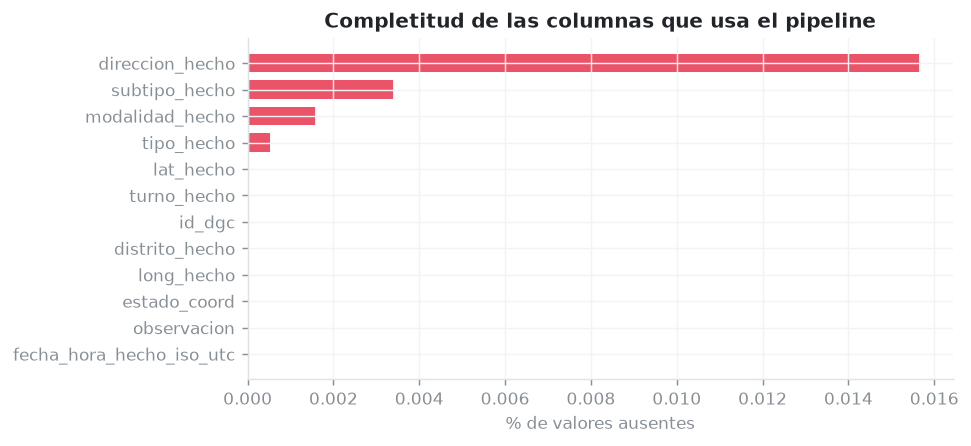

In [3]:
# Nulos por columna: decide qué se puede usar como clave y qué no.
nul = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.barh(nul.index[::-1], nul.values[::-1], color=CRIME, alpha=.85, height=.7)
ax.set_xlabel("% de valores ausentes")
ax.set_title("Completitud de las columnas que usa el pipeline")
for i, v in enumerate(nul.values[::-1]):
    if v > 0.05:
        ax.text(v + .4, i, f"{v:.1f} %", va="center", fontsize=8, color=MUTED)
save(fig, "01-nulos"); plt.show()

## 2 · Duplicados

`id_dgc` **no es único**: una denuncia con varios delitos imputados aparece
repetida, una fila por combinación. Deduplicar solo por `id_dgc` borraría hechos
distintos que comparten expediente.

La clave correcta es `(id_dgc, subtipo_hecho, modalidad_hecho)`: identifica el
hecho concreto dentro de la denuncia.

In [4]:
n = len(df)
dup_id = n - df["id_dgc"].nunique()
key = ["id_dgc", "subtipo_hecho", "modalidad_hecho"]
dup_key = int(df.duplicated(subset=key).sum())

print(f"filas                                    {n:>10,}")
print(f"id_dgc distintos                         {df['id_dgc'].nunique():>10,}")
print(f"  -> repeticiones de id_dgc              {dup_id:>10,}  ({dup_id/n*100:.1f} %)")
print(f"duplicados por (id, subtipo, modalidad)  {dup_key:>10,}  ({dup_key/n*100:.1f} %)")
print()
print("Cuantos delitos distintos lleva una misma denuncia:")
print(df.groupby('id_dgc').size().value_counts().head(6).to_string())

filas                                     3,137,220
id_dgc distintos                          2,963,455
  -> repeticiones de id_dgc                 173,765  (5.5 %)
duplicados por (id, subtipo, modalidad)     145,825  (4.6 %)

Cuantos delitos distintos lleva una misma denuncia:


1    2798652
2     156473
3       7795
4        466
5         52
6          9


  -> reports/eda/02-duplicados.png


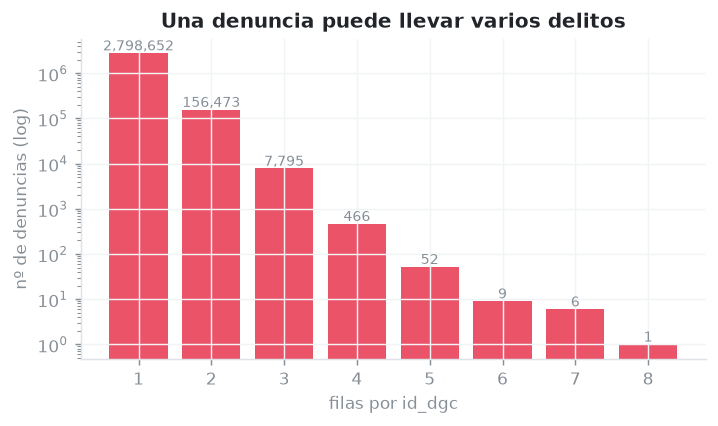

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 3.2))
vc = df.groupby("id_dgc").size().value_counts().sort_index().head(8)
ax.bar(vc.index.astype(str), vc.values, color=CRIME, alpha=.85)
ax.set_yscale("log")
ax.set_xlabel("filas por id_dgc"); ax.set_ylabel("nº de denuncias (log)")
ax.set_title("Una denuncia puede llevar varios delitos")
for x, v in zip(vc.index.astype(str), vc.values):
    ax.text(x, v * 1.15, f"{v:,}", ha="center", fontsize=7.5, color=MUTED)
save(fig, "02-duplicados"); plt.show()

## 3 · Qué `tipo_hecho` conservar

`tipo_hecho` tiene 52 valores. La unidad de análisis del proyecto es la **calle**,
así que solo sirven los hechos que ocurren en el espacio público y tienen una
localización con sentido sobre la red vial.

Se descartan los que son administrativos (`ACCIDENTE DE TRANSITO` va aparte),
de fuero interno, o cuya localización es el domicilio de la víctima y no el
lugar del hecho.

51 valores distintos de tipo_hecho


  -> reports/eda/03-tipos.png


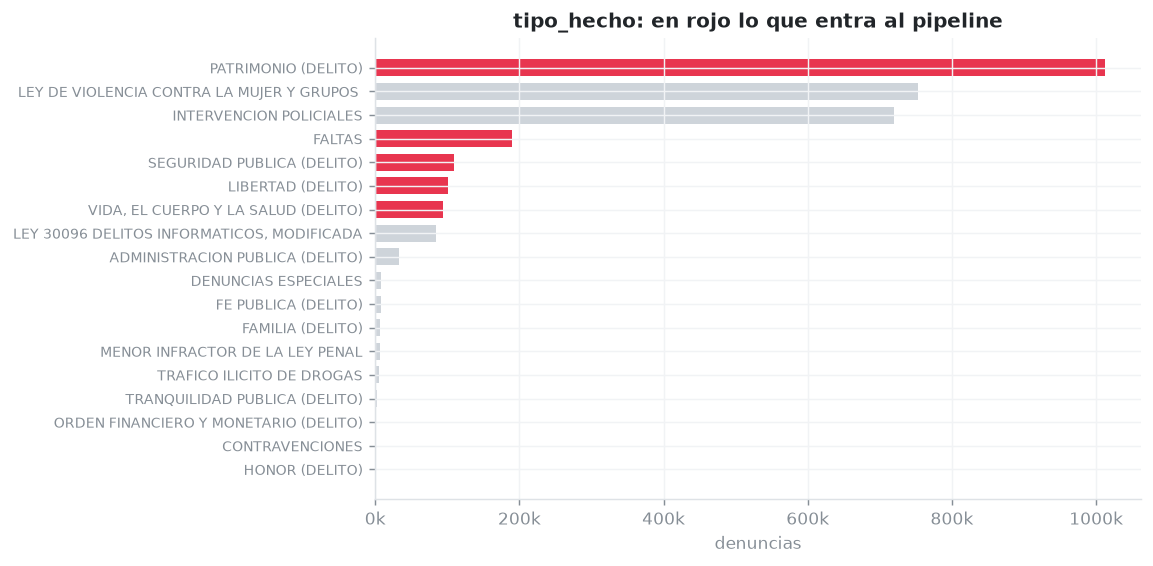


retenido 1,504,498 de 3,137,220  (48.0 %)


In [6]:
KEEP = ["PATRIMONIO (DELITO)", "FALTAS", "SEGURIDAD PUBLICA (DELITO)",
        "VIDA, EL CUERPO Y LA SALUD (DELITO)", "LIBERTAD (DELITO)"]
tipos = df["tipo_hecho"].value_counts()
print(f"{df['tipo_hecho'].nunique()} valores distintos de tipo_hecho")

fig, ax = plt.subplots(figsize=(7.6, 4.6))
top = tipos.head(18)[::-1]
colors = [CRIME if t in KEEP else "#ced4da" for t in top.index]
ax.barh(range(len(top)), top.values, color=colors, height=.72)
ax.set_yticks(range(len(top)))
ax.set_yticklabels([t[:42] for t in top.index], fontsize=8)
ax.set_xlabel("denuncias")
ax.set_title("tipo_hecho: en rojo lo que entra al pipeline")
ax.xaxis.set_major_formatter(lambda v, p: f"{v/1000:.0f}k")
save(fig, "03-tipos"); plt.show()

keep_n = int(tipos[tipos.index.isin(KEEP)].sum())
print(f"\nretenido {keep_n:,} de {len(df):,}  ({keep_n/len(df)*100:.1f} %)")

### `tipo_hecho` es demasiado grueso para ser el eje de categorías

`PATRIMONIO (DELITO)` mete en la misma caja hurto, robo, extorsión y estafa. El
nivel equivalente al `Primary Type` de Chicago —que distingue THEFT de ROBBERY—
es **`subtipo_hecho`**.

Por eso el alcance se decide sobre `tipo_hecho` y el eje de categorías es
`subtipo_hecho`: **35 tipos** dentro de las cinco familias retenidas.

36 subtipos dentro de las 5 familias retenidas

  -> reports/eda/04-subtipos.png


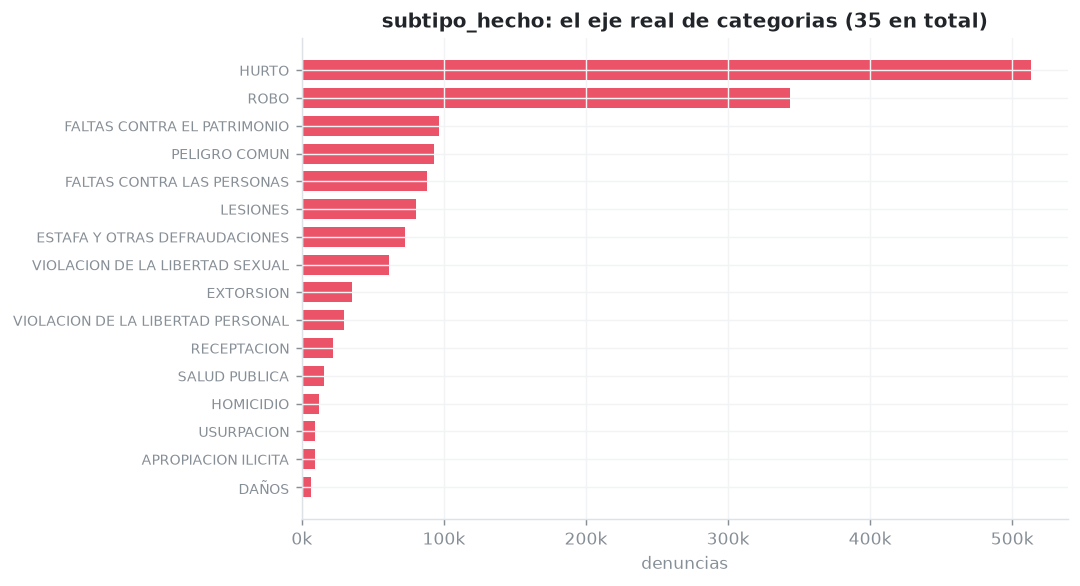

In [7]:
sub = df[df["tipo_hecho"].isin(KEEP)]["subtipo_hecho"].value_counts()
print(f"{len(sub)} subtipos dentro de las 5 familias retenidas\n")

fig, ax = plt.subplots(figsize=(7.6, 4.8))
top = sub.head(16)[::-1]
ax.barh(range(len(top)), top.values, color=CRIME, alpha=.85, height=.72)
ax.set_yticks(range(len(top)))
ax.set_yticklabels([t[:38] for t in top.index], fontsize=8)
ax.set_xlabel("denuncias")
ax.set_title("subtipo_hecho: el eje real de categorias (35 en total)")
ax.xaxis.set_major_formatter(lambda v, p: f"{v/1000:.0f}k")
save(fig, "04-subtipos"); plt.show()

## 4 · ¿Son de fiar las coordenadas?

No todas. El campo `observacion` marca explícitamente las filas cuya coordenada
**no es la del hecho** sino el centroide de la comisaría que registró la
denuncia. Dejarlas dentro pondría miles de crímenes exactamente sobre la puerta
de cada comisaría e inventaría un hotspot en cada una.

In [8]:
obs = df["observacion"].fillna("(sin marca)").value_counts()
print(obs.head(8).to_string())

forzada = int((df["observacion"] == "GEO FORZADA AL CENTROIDE DE COMISARIA").sum())
sin_coord = int(df[["lat_hecho", "long_hecho"]].isna().any(axis=1).sum())
print(f"\ngeo forzada al centroide   {forzada:>10,}  ({forzada/len(df)*100:.1f} %)")
print(f"sin coordenadas            {sin_coord:>10,}  ({sin_coord/len(df)*100:.1f} %)")

observacion
COORDENADA OK                                        1777990
GEO FORZADA AL CENTROIDE DE COMISARIA                1246941
COORDENADA ADECUADA MANUALMENTE                        64801
COORDENADA ADECUADA MANUALMENTE_A CORREGIR UBIGEO      26593
COORDENADA OK_VERIFICAR UBIGEO                         20882
VERIFICAR UBIGEO                                          13

geo forzada al centroide    1,246,941  (39.7 %)
sin coordenadas                     0  (0.0 %)


Los 8 puntos con mas denuncias exactamente en la misma coordenada:

lat_hecho   long_hecho
-12.051163  -77.058724    133151
-11.939356  -76.999332    128072
-11.912435  -77.003037     91160
-12.206707  -76.930859     82979
-12.046373  -77.042754     71535
-11.991546  -77.044550     71424
-12.185359  -76.970095     68498
-12.032644  -77.049018     47204
  -> reports/eda/05-puntos-repetidos.png


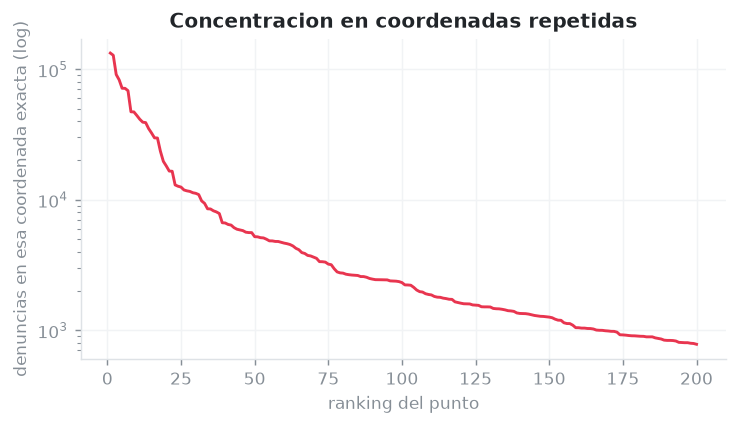

In [9]:
# Puntos que se repiten muchisimas veces = geocodificacion sintetica.
sub_ok = df.dropna(subset=["lat_hecho", "long_hecho"])
pt = sub_ok.groupby(["lat_hecho", "long_hecho"]).size().sort_values(ascending=False)
print("Los 8 puntos con mas denuncias exactamente en la misma coordenada:\n")
print(pt.head(8).to_string())

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.plot(range(1, 201), pt.head(200).values, color=CRIME, lw=1.6)
ax.set_yscale("log")
ax.set_xlabel("ranking del punto"); ax.set_ylabel("denuncias en esa coordenada exacta (log)")
ax.set_title("Concentracion en coordenadas repetidas")
save(fig, "05-puntos-repetidos"); plt.show()

## 5 · La serie temporal, y el hallazgo que condiciona todo lo demás

La serie de denuncias **no** se desploma: sube desde 2021, se estabiliza en
2023-2024 y termina en junio de 2025 simplemente porque ahí acaban los datos.

Lo que sí se desploma es la fracción **utilizable**, y por una razón concreta.

  -> reports/eda/06-serie-mensual.png


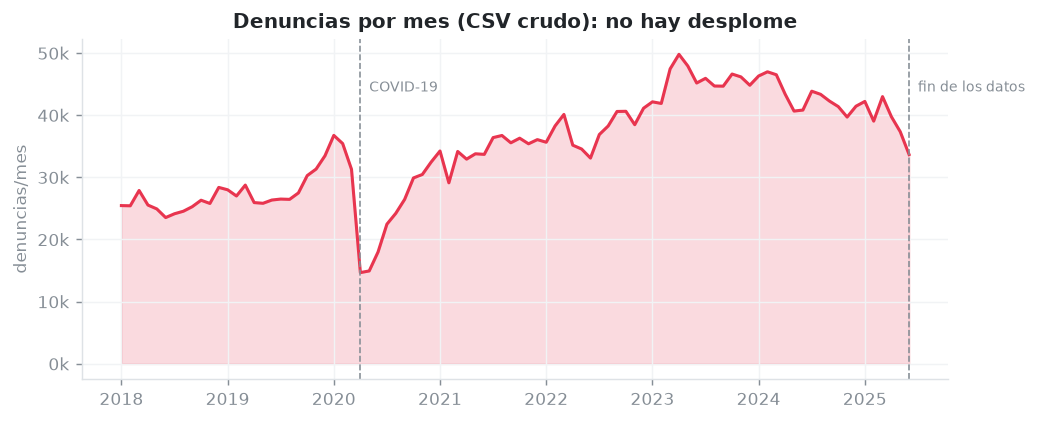

mes
2018    307181
2019    337388
2020    317006
2021    414398
2022    452846
2023    547304
2024    516703
2025    235026


In [10]:
d = df.copy()
d["ts"] = pd.to_datetime(d["fecha_hora_hecho_iso_utc"], errors="coerce", utc=True)
# UTC -> hora local de Lima (UTC-5). Sin esto, los hechos de 19:00-23:59 se
# contarian en el dia siguiente y el perfil horario saldria desplazado.
d["local"] = d["ts"] - pd.Timedelta(hours=5)
d["mes"] = d["local"].dt.to_period("M")
d["anio"] = d["local"].dt.year

serie = d.groupby("mes").size()
serie = serie[(serie.index >= pd.Period("2018-01")) & (serie.index <= pd.Period("2025-12"))]

fig, ax = plt.subplots(figsize=(8.6, 3.4))
ax.fill_between(range(len(serie)), serie.values, color=CRIME, alpha=.18)
ax.plot(range(len(serie)), serie.values, color=CRIME, lw=1.7)
ticks = [i for i, p in enumerate(serie.index) if p.month == 1]
ax.set_xticks(ticks); ax.set_xticklabels([str(serie.index[i].year) for i in ticks])
ax.set_ylabel("denuncias/mes")
ax.set_title("Denuncias por mes (CSV crudo): no hay desplome")
ax.yaxis.set_major_formatter(lambda v, p: f"{v/1000:.0f}k")

# Marcas de los dos eventos que explican la forma de la curva.
for lab, per in [("COVID-19", "2020-04"), ("fin de los datos", "2025-06")]:
    if per in [str(x) for x in serie.index]:
        i = [str(x) for x in serie.index].index(per)
        ax.axvline(i, color=MUTED, ls="--", lw=.9)
        ax.text(i + 1, serie.max() * .88, lab, fontsize=8, color=MUTED)
save(fig, "06-serie-mensual"); plt.show()

print(serie.groupby(serie.index.year).sum().to_string())

### La geocodificación se degrada, y en 2025 colapsa

`estado_coord` dice si la denuncia trae coordenada real. Su evolución es el dato
más importante de este cuaderno:

  -> reports/eda/11-geocodificacion.png


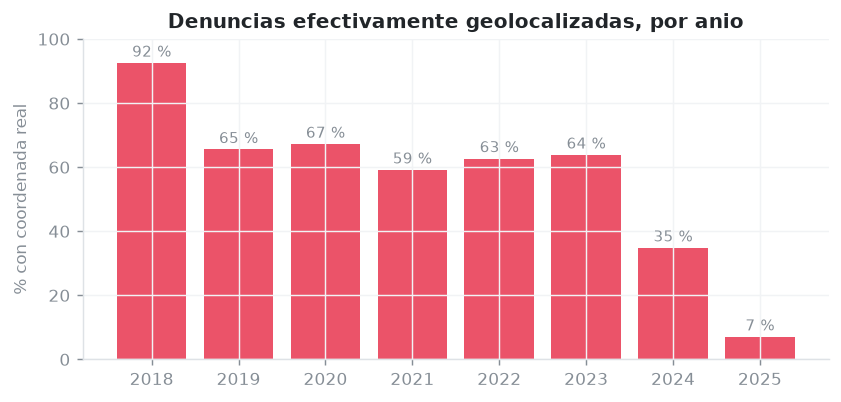

estado_coord  CON COORDENADA  SIN COORDENADA  SIN COORDENADA XX  SIN COORDENADA YY
anio                                                                              
2018                    92.5             7.5                0.0                0.0
2019                    65.5            34.5                0.0                0.0
2020                    67.1            32.9                0.0                0.0
2021                    59.1            40.9                0.0                0.0
2022                    62.6            37.4                0.0                0.0
2023                    63.8            36.2                0.0                0.0
2024                    34.8            65.2                0.0                0.0
2025                     7.0            93.0                0.0                0.0


In [11]:
g = d[(d["anio"] >= 2018) & (d["anio"] <= 2025)]
geo = pd.crosstab(g["anio"], g["estado_coord"].fillna("(nulo)"), normalize="index") * 100
con = geo.get("CON COORDENADA", pd.Series(0, index=geo.index))

fig, ax = plt.subplots(figsize=(7.4, 3.2))
ax.bar(con.index.astype(str), con.values, color=CRIME, alpha=.85)
ax.set_ylabel("% con coordenada real"); ax.set_ylim(0, 100)
ax.set_title("Denuncias efectivamente geolocalizadas, por anio")
for x, v in zip(con.index.astype(str), con.values):
    ax.text(x, v + 2, f"{v:.0f} %", ha="center", fontsize=8.5, color=MUTED)
save(fig, "11-geocodificacion"); plt.show()

print(geo.round(1).to_string())

En 2018 el 92.5 % de las denuncias traía coordenada. En 2024 baja al 34.8 % y en
2025 al **7.0 %**. Las que no la traen reciben el centroide de su comisaría, así
que el pipeline las descarta: usarlas pondría miles de crímenes exactamente
sobre la puerta de cada comisaría.

**Consecuencia para la tesis:** los meses de 2025 se analizan con una fracción
minúscula de lo denunciado. No son comparables con los de 2018-2024, y el menor
número de hotspots que el pipeline detecta en 2025 refleja eso y no una caída
del delito.

findfont: Failed to find font weight 600, now using 700.


  -> reports/eda/12-crudo-vs-utilizable.png


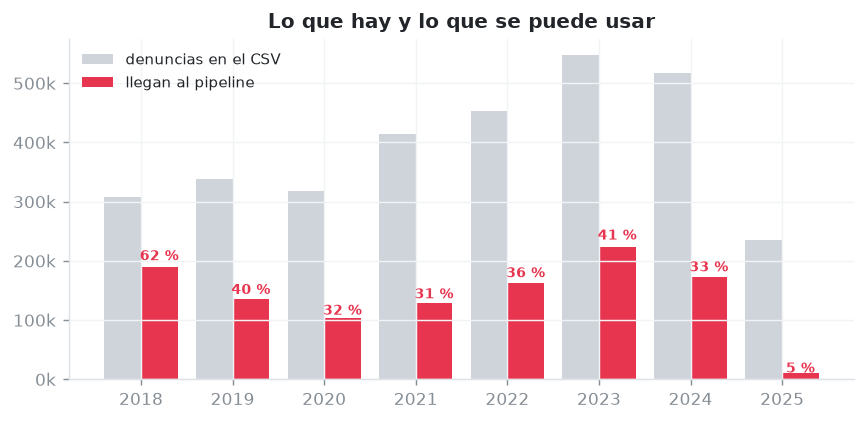

 anio  crudo  utilizable       pct
 2018 307181      189687 61.750890
 2019 337388      135785 40.245948
 2020 317006      102789 32.424938
 2021 414398      128884 31.101501
 2022 452846      162433 35.869368
 2023 547304      222431 40.641216
 2024 516703      171854 33.259726
 2025 235026       10605  4.512267


In [12]:
KEEPSET = set(KEEP)
rows = []
for y, w in g.groupby("anio"):
    a = len(w)
    w2 = w[w["tipo_hecho"].isin(KEEPSET)]
    w3 = w2[w2["observacion"] != "GEO FORZADA AL CENTROIDE DE COMISARIA"]
    ok = int(w3[["lat_hecho", "long_hecho"]].notna().all(axis=1).sum())
    rows.append((y, a, ok, ok / a * 100))
res = pd.DataFrame(rows, columns=["anio", "crudo", "utilizable", "pct"])

fig, ax = plt.subplots(figsize=(7.8, 3.4))
x = np.arange(len(res))
ax.bar(x - .2, res["crudo"], .4, label="denuncias en el CSV", color="#ced4da")
ax.bar(x + .2, res["utilizable"], .4, label="llegan al pipeline", color=CRIME)
ax.set_xticks(x); ax.set_xticklabels(res["anio"].astype(str))
ax.yaxis.set_major_formatter(lambda v, p: f"{v/1000:.0f}k")
ax.legend(frameon=False, fontsize=8.5)
ax.set_title("Lo que hay y lo que se puede usar")
for i, r in res.iterrows():
    ax.text(i + .2, r["utilizable"] * 1.06, f"{r['pct']:.0f} %",
            ha="center", fontsize=8, color=CRIME, fontweight="600")
save(fig, "12-crudo-vs-utilizable"); plt.show()
print(res.to_string(index=False))

  -> reports/eda/07-perfil-temporal.png


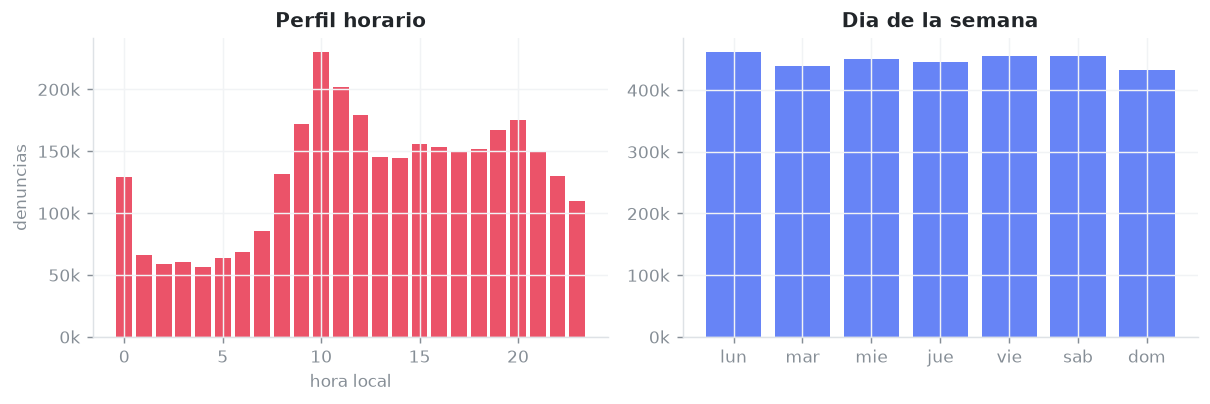

hora pico: 10:00 con 229,906 denuncias
medianoche (0:00): 129,146  <- picos en horas redondas = hora imputada


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.2))

# Perfil horario, en hora local.
h = d["local"].dt.hour.value_counts().sort_index()
axes[0].bar(h.index, h.values, color=CRIME, alpha=.85)
axes[0].set_xlabel("hora local"); axes[0].set_ylabel("denuncias")
axes[0].set_title("Perfil horario")
axes[0].yaxis.set_major_formatter(lambda v, p: f"{v/1000:.0f}k")

# Dia de la semana.
dias = ["lun", "mar", "mie", "jue", "vie", "sab", "dom"]
w = d["local"].dt.dayofweek.value_counts().sort_index()
axes[1].bar(range(7), w.reindex(range(7)).values, color=ACCENT[2], alpha=.85)
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(dias)
axes[1].set_title("Dia de la semana")
axes[1].yaxis.set_major_formatter(lambda v, p: f"{v/1000:.0f}k")
plt.tight_layout()
save(fig, "07-perfil-temporal"); plt.show()

pico = h.idxmax()
print(f"hora pico: {pico}:00 con {h.max():,} denuncias")
print(f"medianoche (0:00): {h.get(0, 0):,}  <- picos en horas redondas = hora imputada")

## 6 · Geografía

43 distritos. La distribución es muy desigual, y eso es esperable: San Juan de
Lurigancho tiene un millón de habitantes y Santa María del Mar unos mil.

43 distritos


  -> reports/eda/08-distritos.png


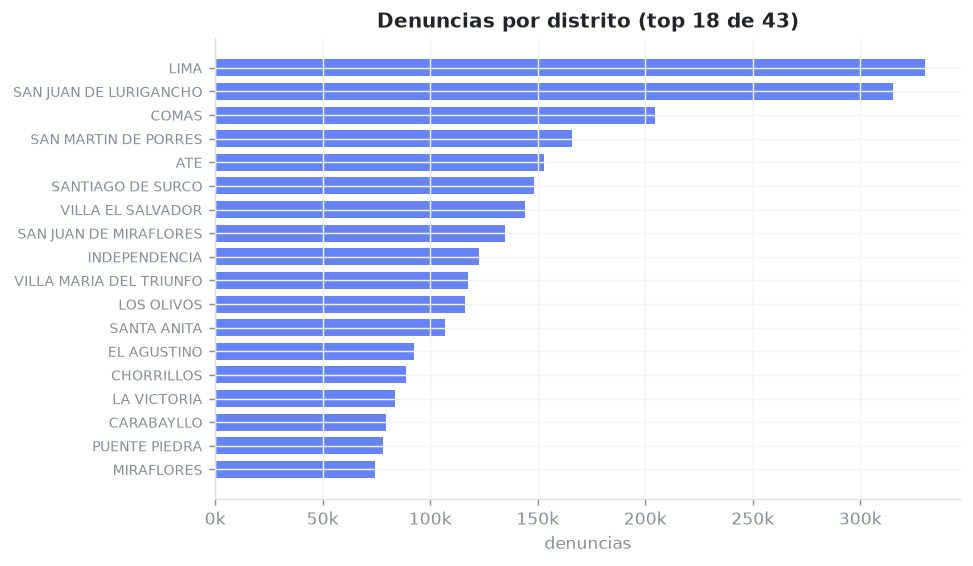

In [14]:
dist = df["distrito_hecho"].value_counts()
print(f"{len(dist)} distritos")

fig, ax = plt.subplots(figsize=(7.4, 4.6))
top = dist.head(18)[::-1]
ax.barh(range(len(top)), top.values, color=ACCENT[2], alpha=.85, height=.72)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=8)
ax.set_xlabel("denuncias")
ax.set_title("Denuncias por distrito (top 18 de 43)")
ax.xaxis.set_major_formatter(lambda v, p: f"{v/1000:.0f}k")
save(fig, "08-distritos"); plt.show()

  -> reports/eda/09-nube.png


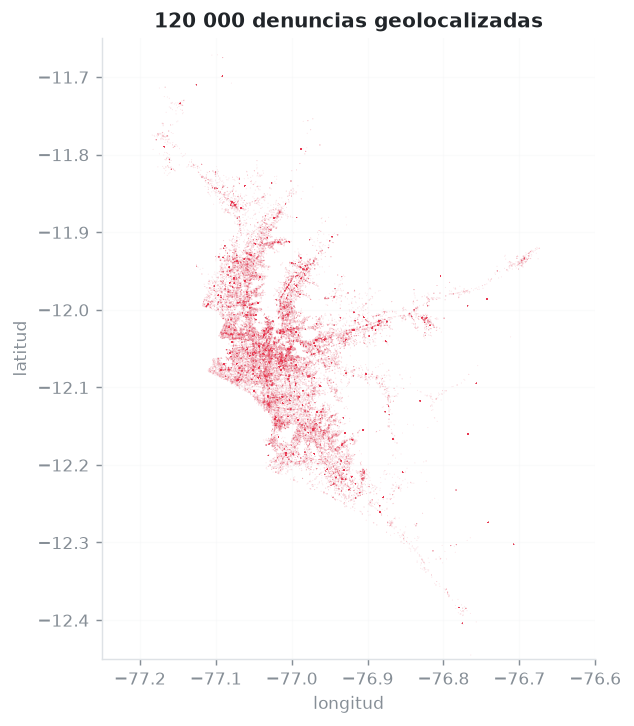

In [15]:
# Nube de puntos: la forma de Lima sale sola, y con ella los artefactos.
s = sub_ok.sample(min(120_000, len(sub_ok)), random_state=0)
fig, ax = plt.subplots(figsize=(5.6, 6.2))
ax.scatter(s["long_hecho"], s["lat_hecho"], s=.35, alpha=.13, color=CRIME,
           edgecolors="none")
ax.set_xlim(-77.25, -76.6); ax.set_ylim(-12.45, -11.65)
ax.set_xlabel("longitud"); ax.set_ylabel("latitud")
ax.set_title("120 000 denuncias geolocalizadas")
ax.set_aspect(1 / np.cos(np.radians(12)))
ax.grid(alpha=.3)
save(fig, "09-nube"); plt.show()

## 7 · Del CSV al pipeline: el embudo

Resumen de todo lo anterior, en el orden en que el ingestor lo aplica.

  -> reports/eda/10-embudo.png


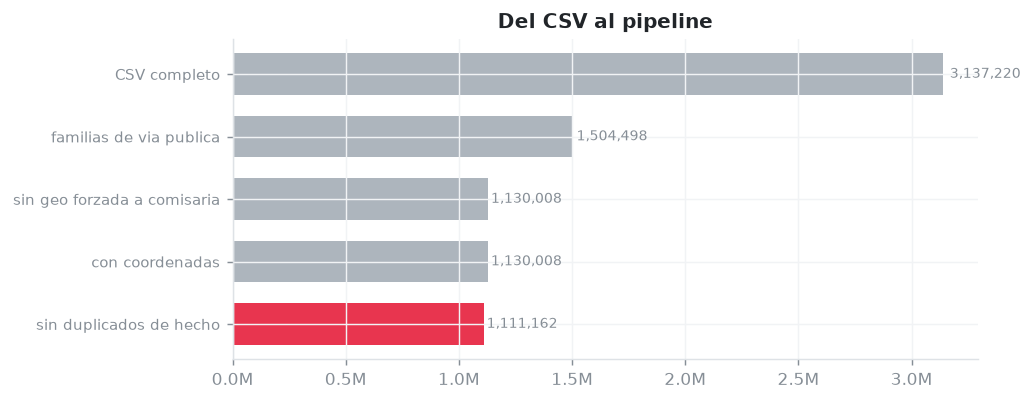

etapa                                  filas   % del CSV
CSV completo                       3,137,220      100.0 %
familias de via publica            1,504,498       48.0 %
sin geo forzada a comisaria        1,130,008       36.0 %
con coordenadas                    1,130,008       36.0 %
sin duplicados de hecho            1,111,162       35.4 %


In [16]:
etapas = []
n0 = len(df)
etapas.append(("CSV completo", n0))

m = df["tipo_hecho"].isin(KEEP)
etapas.append(("familias de via publica", int(m.sum())))

w = df[m]
m2 = w["observacion"] != "GEO FORZADA AL CENTROIDE DE COMISARIA"
etapas.append(("sin geo forzada a comisaria", int(m2.sum())))

w2 = w[m2]
m3 = w2[["lat_hecho", "long_hecho"]].notna().all(axis=1)
etapas.append(("con coordenadas", int(m3.sum())))

w3 = w2[m3]
etapas.append(("sin duplicados de hecho",
               int(len(w3) - w3.duplicated(subset=key).sum())))

fig, ax = plt.subplots(figsize=(7.4, 3.2))
labels = [e[0] for e in etapas][::-1]
vals = [e[1] for e in etapas][::-1]
ax.barh(range(len(vals)), vals, color=[ACCENT[0]] + ["#adb5bd"] * 4, height=.66)
ax.set_yticks(range(len(vals))); ax.set_yticklabels(labels, fontsize=8.5)
ax.xaxis.set_major_formatter(lambda v, p: f"{v/1e6:.1f}M")
ax.set_title("Del CSV al pipeline")
for i, v in enumerate(vals):
    ax.text(v * 1.01, i, f"{v:,}", va="center", fontsize=8, color=MUTED)
save(fig, "10-embudo"); plt.show()

print(f"{'etapa':<32}{'filas':>12}{'% del CSV':>12}")
for name, v in etapas:
    print(f"{name:<32}{v:>12,}{v/n0*100:>11.1f} %")

## Conclusiones

1. **Seis columnas de 58** bastan para el pipeline; el resto es jerarquía
   administrativa redundante.
2. **`id_dgc` no es clave.** La clave del hecho es
   `(id_dgc, subtipo_hecho, modalidad_hecho)`; deduplicar solo por el
   identificador borraría delitos distintos de la misma denuncia.
3. **El alcance se decide sobre `tipo_hecho`** (cinco familias de vía pública) y
   **el eje de categorías es `subtipo_hecho`** (35 tipos). Usar `tipo_hecho`
   como eje colapsaría hurto, robo y extorsión en una sola caja.
4. **Las coordenadas marcadas como centroide de comisaría hay que quitarlas**:
   inventarían un hotspot en cada comisaría.
5. **La geocodificación se degrada y en 2025 colapsa.** El CSV crudo no baja;
   lo que baja es la fracción con coordenada real: 92.5 % en 2018, 34.8 % en
   2024, **7.0 % en 2025**. Solo el 4.5 % de las denuncias de 2025 llega al
   pipeline. Los hotspots de 2025 se calculan sobre esa fracción y **no son
   comparables** con los de años anteriores; conviene decirlo en cualquier
   lectura de la serie, o truncar la ventana en 2024.